## RestNet50

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.2606 - loss: 5.1333 - val_accuracy: 0.2653 - val_loss: 2.3937
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.2772 - loss: 2.5692 - val_accuracy: 0.2041 - val_loss: 4.5538
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2954 - loss: 2.5046 - val_accuracy: 0.2653 - val_loss: 2.1834
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2959 - loss: 2.1879 - val_accuracy: 0.2041 - val_loss: 3.0162
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3076 - loss: 1.8476 - val_accuracy: 0.3265 - val_loss: 1.9644
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.3101 - loss: 1.4734 - val_accuracy: 0.3265 - val_loss: 1.9856
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.3270 - loss: 1.6114 - val_accuracy: 0.2449 - val_loss: 1.6893
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━

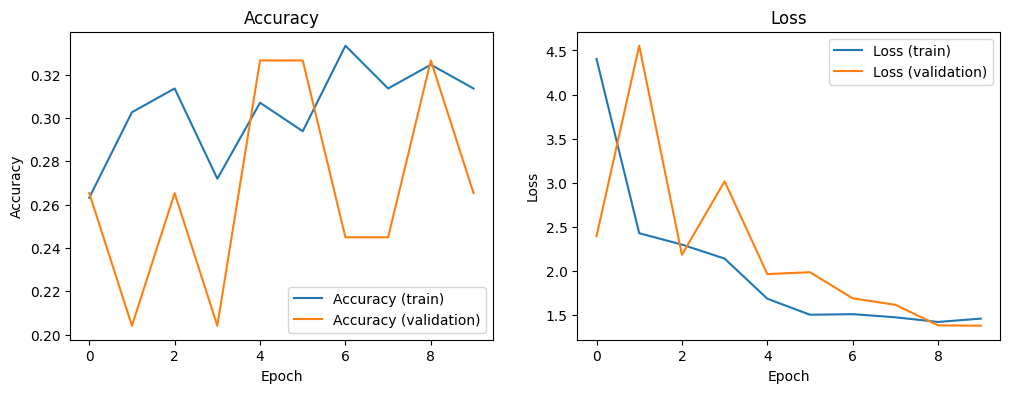

In [6]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save('ResNet50.h5')



In [7]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('ResNet50.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (150, 150))
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━

## ResNet101

Found 456 images belonging to 4 classes.


Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.3352 - loss: 51.7447 - val_accuracy: 0.5306 - val_loss: 2.7399
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7580 - loss: 1.4923 - val_accuracy: 0.6531 - val_loss: 1.5814
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8711 - loss: 0.5569 - val_accuracy: 0.5306 - val_loss: 2.7784
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8853 - loss: 0.5266 - val_accuracy: 0.9184 - val_loss: 0.3730
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9143 - loss: 0.3514 - val_accuracy: 0.8571 - val_loss: 0.5223
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9664 - loss: 0.0946 - val_accuracy: 0.8980 - val_loss: 0.1926
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9639 - loss: 0.0960 - val_accuracy: 0.8980 - val_loss: 0.3033
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9792 - loss: 

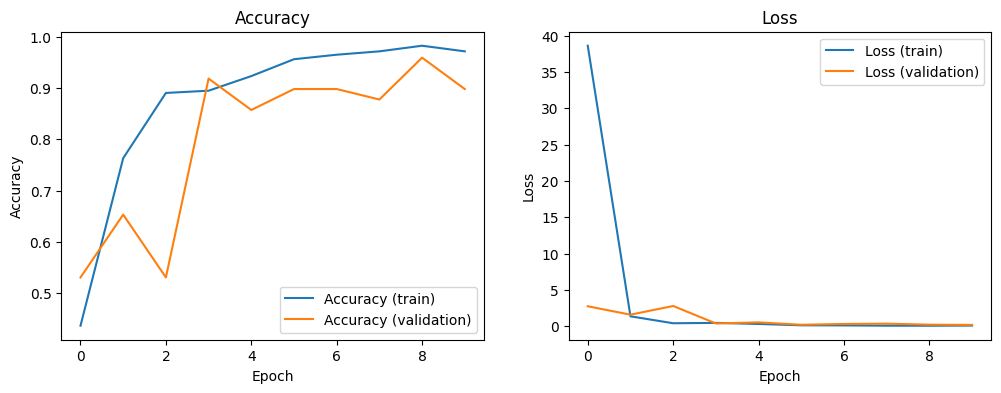

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input  # Correct import
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Using the correct preprocessing function
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec ResNet101
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)


model.save('ResNet101.h5')


In [9]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('ResNet101.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (150, 150))
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1

## RestNet152

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.


Epoch 1/10


c:\Users\Nessrine\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.2273 - loss: 11.6362 - val_accuracy: 0.2041 - val_loss: 6.9734
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.2734 - loss: 3.5308 - val_accuracy: 0.2653 - val_loss: 2.5734
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.2849 - loss: 1.9129 - val_accuracy: 0.2449 - val_loss: 1.5322
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.3034 - loss: 1.7128 - val_accuracy: 0.2857 - val_loss: 1.8072
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.3093 - loss: 1.6408 - val_accuracy: 0.2449 - val_loss: 1.5877
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.3091 - loss: 1.9707 - val_accuracy: 0.3265 - val_loss: 1.7645
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.3152 - loss: 1.6461 - val_accuracy: 0.3265 - val_loss: 1.5866
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.3605 - loss: 1.5794 - val_accuracy: 0.2245 - val_loss: 2.6896
Ep

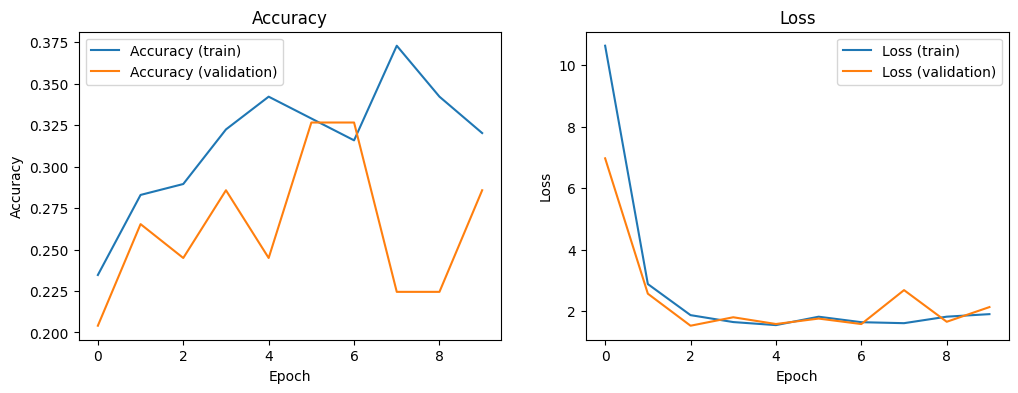

In [10]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet152
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec ResNet152
base_model = ResNet152(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save('ResNet152.h5')


In [11]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('ResNet152.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (150, 150))
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

## VGG16

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10


c:\Users\Nessrine\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.3164 - loss: 3.3771 - val_accuracy: 0.3061 - val_loss: 1.5232
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5341 - loss: 1.0344 - val_accuracy: 0.4898 - val_loss: 1.0889
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7318 - loss: 0.7853 - val_accuracy: 0.5102 - val_loss: 1.0065
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7419 - loss: 0.6522 - val_accuracy: 0.5306 - val_loss: 0.8005
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8512 - loss: 0.4789 - val_accuracy: 0.5918 - val_loss: 0.7339
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8698 - loss: 0.4267 - val_accuracy: 0.7755 - val_loss: 0.5925
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8664 - loss: 0.4103 - val_accuracy: 0.8571 - val_loss: 0.5571
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8604 - loss: 0.4294 - val_accuracy: 0.7347 - val_loss: 0.7145
Epo

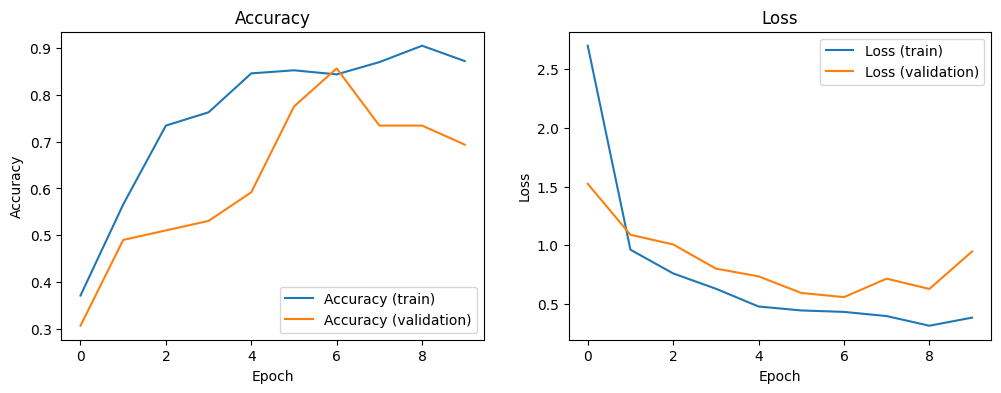

In [12]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)
model.save('VGG16.h5')


In [13]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('VGG16.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (150, 150))
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━

## vGG119

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.2713 - loss: 3.8827 - val_accuracy: 0.3673 - val_loss: 1.4170
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.3966 - loss: 1.3743 - val_accuracy: 0.2653 - val_loss: 1.2807
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5583 - loss: 1.0815 - val_accuracy: 0.4694 - val_loss: 1.0233
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.6906 - loss: 0.9089 - val_accuracy: 0.6327 - val_loss: 1.0002
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.6950 - loss: 0.7583 - val_accuracy: 0.7143 - val_loss: 0.7540
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7406 - loss: 0.6847 - val_accuracy: 0.6939 - val_loss: 0.8265
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8046 - loss: 0.5672 - val_accuracy: 0.6939 - val_loss: 0.6802
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━

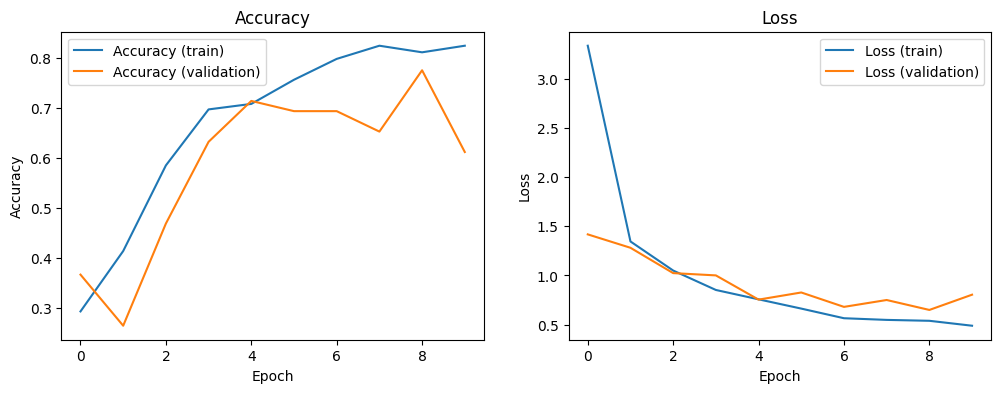

In [14]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec VGG19
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)
model.save("VGG19.h5")


In [15]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('VGG19.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (150, 150))
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

## MobileNet

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 822ms/step - accuracy: 0.3876 - loss: 1.6874 - val_accuracy: 0.4694 - val_loss: 1.0117
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 722ms/step - accuracy: 0.7956 - loss: 0.5219 - val_accuracy: 0.8980 - val_loss: 0.4497
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 766ms/step - accuracy: 0.9335 - loss: 0.2928 - val_accuracy: 0.9388 - val_loss: 0.3264
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 774ms/step - accuracy: 0.9474 - loss: 0.1951 - val_accuracy: 0.7551 - val_loss: 0.4750
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 754ms/step - accuracy: 0.9394 - loss: 0.1757 - val_accuracy: 0.8980 - val_loss: 0.3208
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 768ms/step - accuracy: 0.9515 - loss: 0.1314 - val_accuracy: 1.0000 - val_loss: 0.1301
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 796ms/step - accuracy: 0.9639 - loss: 0.1128 - val_accuracy: 0.9184 - val_loss: 0.1237
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 730ms/step - accuracy: 0.9892 - loss: 0.0716 - val_accu

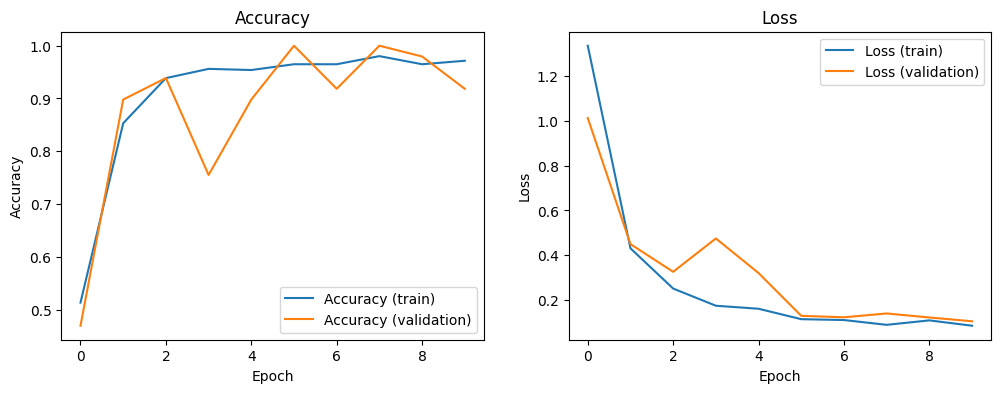

In [16]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNet
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # MobileNet utilise des tailles d'image plus grandes
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # MobileNet utilise des tailles d'image plus grandes
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec MobileNet
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("MobileNet.h5")


In [31]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('MobileNet.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 924ms/step


## MobileNetV2


Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4225 - loss: 1.8844 - val_accuracy: 0.6939 - val_loss: 0.9958
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 836ms/step - accuracy: 0.8305 - loss: 0.5758 - val_accuracy: 0.7347 - val_loss: 0.7122
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 858ms/step - accuracy: 0.8786 - loss: 0.3827 - val_accuracy: 0.8980 - val_loss: 0.3984
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 882ms/step - accuracy: 0.9172 - loss: 0.2713 - val_accuracy: 0.9388 - val_loss: 0.3048
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 846ms/step - accuracy: 0.9494 - loss: 0.2321 - val_accuracy: 0.8571 - val_loss: 0.3751
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 880ms/step - accuracy: 0.9612 - loss: 0.1650 - val_accuracy: 0.8980 - val_loss: 0.3199
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 873ms/step - accuracy: 0.9445 - loss: 0.1629 - val_accuracy: 0.8367 - val_loss: 0.3214
Epoch 8/10
15/15 ━━

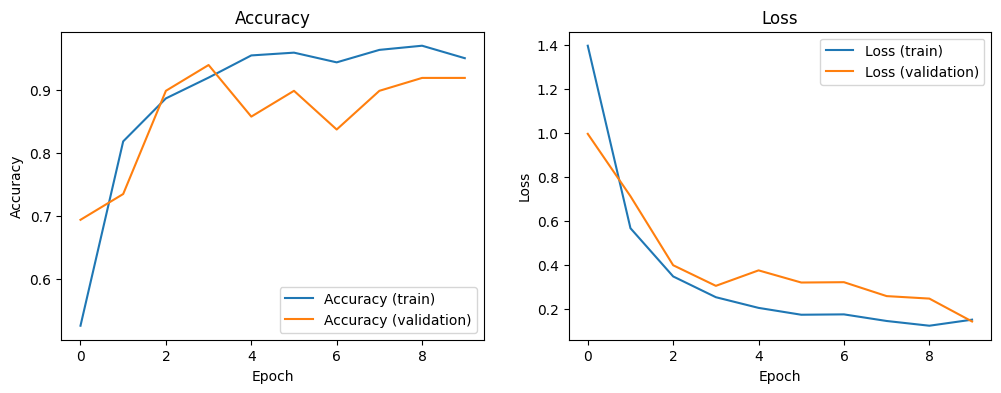

In [20]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # MobileNetV2 utilise des tailles d'image plus grandes
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # MobileNetV2 utilise des tailles d'image plus grandes
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("MobileNetV2.h5")


In [30]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('MobileNetV2.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


## DenseNet201

Found 456 images belonging to 4 classes.


Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.3691 - loss: 1.6993 - val_accuracy: 0.7551 - val_loss: 0.8177
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.8719 - loss: 0.5037 - val_accuracy: 0.8776 - val_loss: 0.4530
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9468 - loss: 0.2648 - val_accuracy: 1.0000 - val_loss: 0.2408
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9376 - loss: 0.2003 - val_accuracy: 0.9388 - val_loss: 0.1999
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9778 - loss: 0.1310 - val_accuracy: 0.9388 - val_loss: 0.1487
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9825 - loss: 0.0920 - val_accuracy: 0.9388 - val_loss: 0.1239
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.9745 - loss: 0.0992 - val_accuracy: 1.0000 - val_loss: 0.0875
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9775 - loss: 0

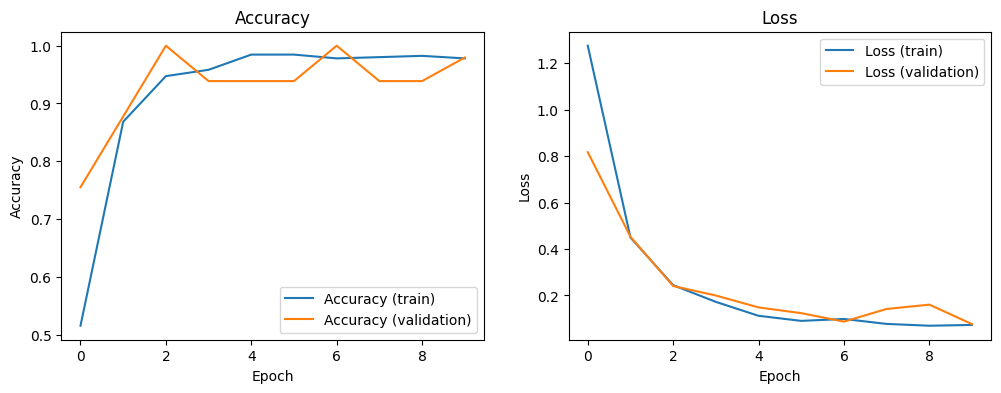

In [5]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet201
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # DenseNet201 utilise une taille d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # DenseNet201 utilise une taille d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec DenseNet201
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("DenseNet201.h5")


In [6]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('DenseNet201.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img




cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


##  InceptionV3

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.2861 - loss: 2.4917 - val_accuracy: 0.3878 - val_loss: 1.1960
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5142 - loss: 1.0572 - val_accuracy: 0.8571 - val_loss: 0.8879
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8070 - loss: 0.7149 - val_accuracy: 0.6735 - val_loss: 0.8067
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8361 - loss: 0.5693 - val_accuracy: 0.8776 - val_loss: 0.5957
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8691 - loss: 0.4493 - val_accuracy: 0.8980 - val_loss: 0.4753
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9313 - loss: 0.3329 - val_accuracy: 0.9184 - val_loss: 0.4453
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9335 - loss: 0.2931 - val_accuracy: 0.8571 - val_loss: 0.5821
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━

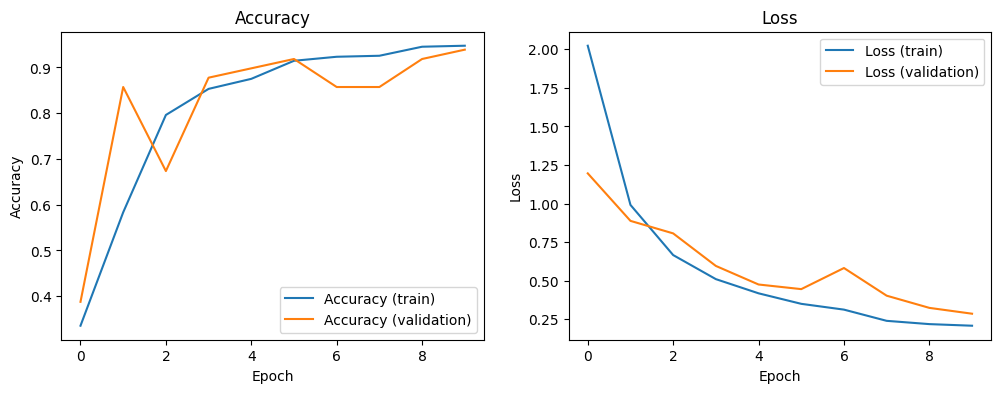

In [3]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(299, 299),  # InceptionV3 utilise des tailles d'image de 299x299
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(299, 299),  # InceptionV3 utilise des tailles d'image de 299x299
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec InceptionV3
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("InceptionV3.h5")


In [4]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('InceptionV3.h5')

def preprocess_for_prediction(img):
    img = cv2.resize(img, (299, 299))  # Resize to 299x299
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━

## NASNetLarge

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 286s 12s/step - accuracy: 0.4314 - loss: 1.5046 - val_accuracy: 0.6939 - val_loss: 0.7540
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 174s 11s/step - accuracy: 0.8553 - loss: 0.5005 - val_accuracy: 0.7551 - val_loss: 0.5759
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 197s 13s/step - accuracy: 0.9174 - loss: 0.2789 - val_accuracy: 0.8776 - val_loss: 0.2747
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 172s 11s/step - accuracy: 0.9048 - loss: 0.2770 - val_accuracy: 0.7755 - val_loss: 0.4610
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 191s 13s/step - accuracy: 0.9362 - loss: 0.1941 - val_accuracy: 0.7959 - val_loss: 0.3561
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 185s 12s/step - accuracy: 0.9444 - loss: 0.1563 - val_accuracy: 0.9184 - val_loss: 0.2464
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 470s 32s/step - accuracy: 0.9770 - loss: 0.0912 - val_accuracy: 0.9184 - val_loss: 0.1991
Epoch 8/10
15/15 ━━━━━━

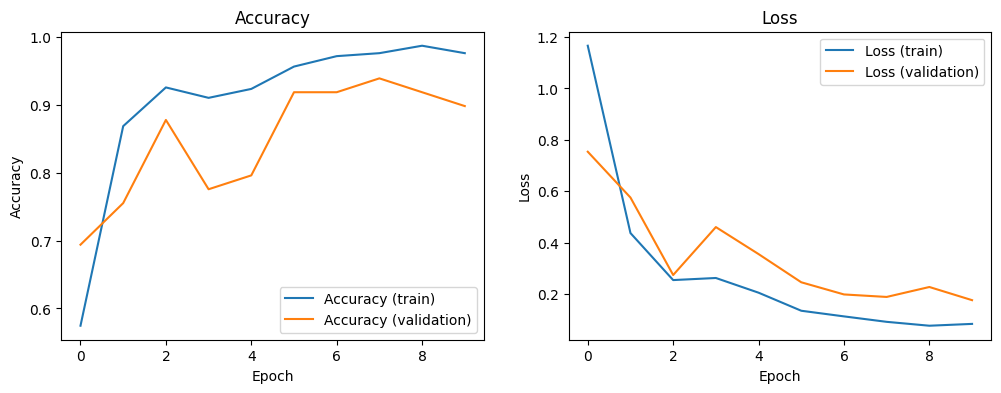

In [7]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import NASNetLarge
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(331, 331),  # NASNetLarge utilise des tailles d'image de 331x331
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(331, 331),  # NASNetLarge utilise des tailles d'image de 331x331
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec NASNetLarge
base_model = NASNetLarge(weights='imagenet', include_top=False, input_shape=(331, 331, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("NASNetLarge.h5")


In [29]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('NASNetLarge.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (331, 331))  # Resize to 331x331 for NASNetLarge
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img


cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422m

## NASNetMobile

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.4287 - loss: 1.3905 - val_accuracy: 0.5306 - val_loss: 1.0626
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 997ms/step - accuracy: 0.7582 - loss: 0.7160 - val_accuracy: 0.6735 - val_loss: 0.6662
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 977ms/step - accuracy: 0.8464 - loss: 0.4527 - val_accuracy: 0.9184 - val_loss: 0.3903
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8989 - loss: 0.3680 - val_accuracy: 0.7755 - val_loss: 0.5036
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 981ms/step - accuracy: 0.9016 - loss: 0.2954 - val_accuracy: 0.9796 - val_loss: 0.2038
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8961 - loss: 0.2684 - val_accuracy: 0.9184 - val_loss: 0.2619
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 979ms/step - accuracy: 0.8934 - loss: 0.2849 - val_accuracy: 0.9184 - val_loss: 0.2268
Epoch 8/10
15/15 ━━━━━━━━

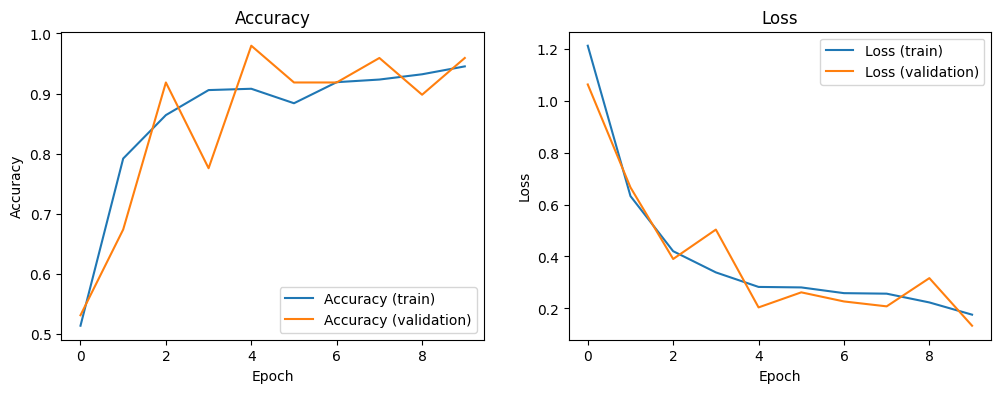

In [9]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import NASNetMobile
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # NASNetMobile utilise des tailles d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # NASNetMobile utilise des tailles d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec NASNetMobile
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)


model.save("NASNetMobile.h5")

In [10]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('NASNetMobile.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img


cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 

## ResNet101V2

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.4388 - loss: 1.7528 - val_accuracy: 0.8571 - val_loss: 0.5117
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8451 - loss: 0.4614 - val_accuracy: 0.8367 - val_loss: 0.4447
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8990 - loss: 0.2966 - val_accuracy: 0.8367 - val_loss: 0.3874
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9546 - loss: 0.1544 - val_accuracy: 0.9184 - val_loss: 0.2196
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.9521 - loss: 0.1440 - val_accuracy: 0.9796 - val_loss: 0.1224
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9648 - loss: 0.1500 - val_accuracy: 0.9388 - val_loss: 0.1411
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9770 - loss: 0.0981 - val_accuracy: 0.9592 - val_loss: 0.1106
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━

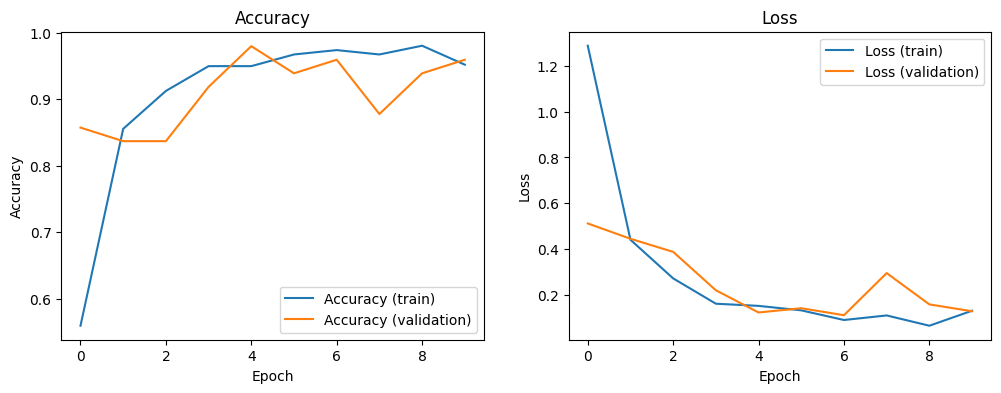

In [11]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet101V2
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # ResNet101V2 utilise des tailles d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # ResNet101V2 utilise des tailles d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec ResNet101V2
base_model = ResNet101V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("ResNet101V2.h5")


In [12]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('ResNet101V2.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step


## ResNet50

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.2866 - loss: 1.6697 - val_accuracy: 0.2653 - val_loss: 1.5208
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2598 - loss: 1.5782 - val_accuracy: 0.2449 - val_loss: 1.4504
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.3129 - loss: 1.3959 - val_accuracy: 0.1429 - val_loss: 1.5029
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.3179 - loss: 1.3943 - val_accuracy: 0.2041 - val_loss: 1.5274
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2889 - loss: 1.3878 - val_accuracy: 0.2041 - val_loss: 1.6466
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.3420 - loss: 1.3837 - val_accuracy: 0.2245 - val_loss: 1.6790
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.2868 - loss: 1.4216 - val_accuracy: 0.1429 - val_loss: 1.6679
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━

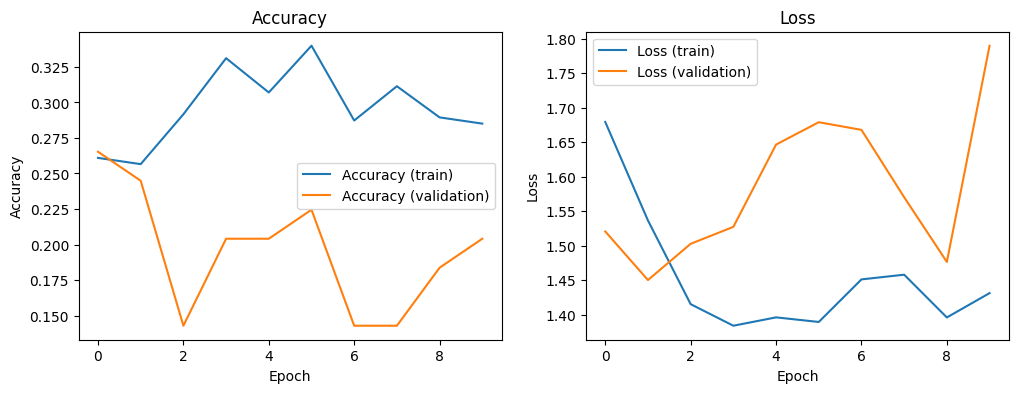

In [13]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # ResNet50 utilise des tailles d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # ResNet50 utilise des tailles d'image de 224x224
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle avec ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)


model.save("ResNet50.h5")


In [14]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('ResNet50.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img


cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


## CNN 2D

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.


c:\Users\Nessrine\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 495ms/step - accuracy: 0.2576 - loss: 1.5230 - val_accuracy: 0.2041 - val_loss: 1.3861
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 472ms/step - accuracy: 0.3357 - loss: 1.3250 - val_accuracy: 0.6122 - val_loss: 1.1154
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 465ms/step - accuracy: 0.5539 - loss: 0.9597 - val_accuracy: 0.5510 - val_loss: 0.8408
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 481ms/step - accuracy: 0.5218 - loss: 0.8600 - val_accuracy: 0.6735 - val_loss: 0.9117
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.5945 - loss: 0.7877 - val_accuracy: 0.5714 - val_loss: 0.8561
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 445ms/step - accuracy: 0.6261 - loss: 0.7736 - val_accuracy: 0.2653 - val_loss: 1.2592
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 457ms/step - accuracy: 0.5998 - loss: 0.8035 - val_accuracy: 0.6122 - val_loss: 0.8905
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 458ms/step - accuracy: 0.7399 - loss: 0.6348 - val_accuracy: 

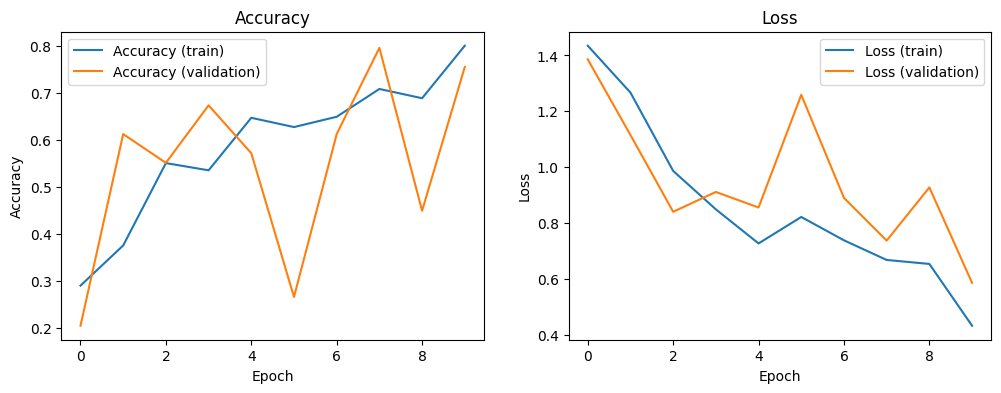

In [15]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # Taille des images
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),  # Taille des images
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle CNN
model = models.Sequential()

# Couche de convolution et pooling 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Couche de convolution et pooling 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Couche de convolution et pooling 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Couche de convolution et pooling 4
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Couche d'aplatissement
model.add(layers.Flatten())

# Couche fully connected
model.add(layers.Dense(512, activation='relu'))

# Couche de sortie
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

# Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("CNN2D.h5")


In [25]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('CNN2D.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (150, 150))
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


## LSTM

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 506ms/step - accuracy: 0.2965 - loss: 1.3749 - val_accuracy: 0.3673 - val_loss: 1.3702
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 512ms/step - accuracy: 0.3660 - loss: 1.3070 - val_accuracy: 0.5714 - val_loss: 1.1261
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 481ms/step - accuracy: 0.6639 - loss: 0.8568 - val_accuracy: 0.7347 - val_loss: 0.5715
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.7991 - loss: 0.4774 - val_accuracy: 0.7347 - val_loss: 0.5970
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 449ms/step - accuracy: 0.8465 - loss: 0.4183 - val_accuracy: 0.8367 - val_loss: 0.5058
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 430ms/step - accuracy: 0.8781 - loss: 0.3206 - val_accuracy: 0.8776 - val_loss: 0.3357
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 440ms/step - accuracy: 0.8884 - loss: 0.2635 - val_accuracy: 0.6531 - val_loss: 0.7842
Epoch 8/10
15/15 ━━━

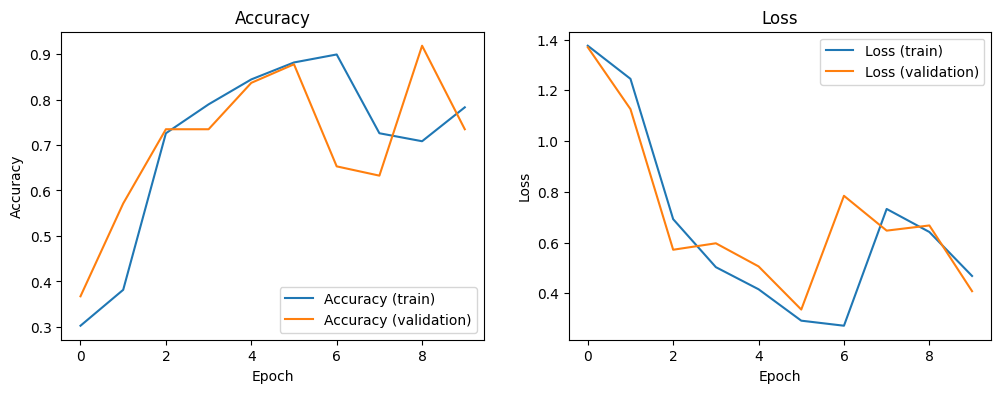

In [17]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Création des générateurs d'images pour la formation et la validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Création du modèle CNN + LSTM
model = models.Sequential()

# CNN pour l'extraction des caractéristiques
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Aplatissement et mise en forme pour LSTM
model.add(layers.TimeDistributed(layers.Flatten()))
model.add(layers.LSTM(64, return_sequences=False))

# Fully Connected Layer
model.add(layers.Dense(512, activation='relu'))

# Couche de sortie
model.add(layers.Dense(len(train_generator.class_indices), activation='softmax'))

# Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)


model.save("LSTM.h5")


In [24]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('LSTM.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (150, 150))
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img

cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━

## ResNet50 avec Transfert d'Apprentissage

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Epoch 1/10


c:\Users\Nessrine\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.4772 - loss: 1.9744 - val_accuracy: 0.4286 - val_loss: 1.3790
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8227 - loss: 0.4321 - val_accuracy: 0.8367 - val_loss: 0.4073
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8935 - loss: 0.2699 - val_accuracy: 0.8776 - val_loss: 0.2703
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9541 - loss: 0.1302 - val_accuracy: 0.9184 - val_loss: 0.2115
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9708 - loss: 0.0910 - val_accuracy: 0.8980 - val_loss: 0.1542
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9723 - loss: 0.0983 - val_accuracy: 0.8980 - val_loss: 0.3421
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9519 - loss: 0.1051 - val_accuracy: 0.9796 - val_loss: 0.1205
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9779 - loss: 0.0764 - val_accuracy: 1.0000 - val_loss: 0.0962
Epo

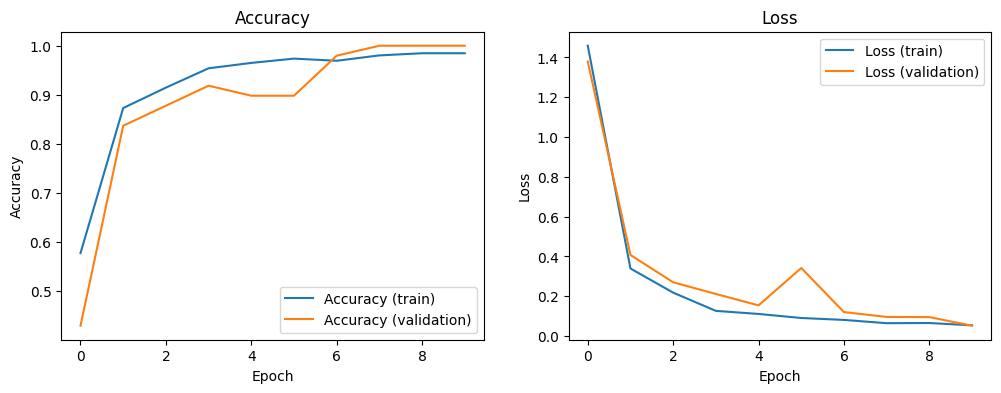

In [39]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Générateurs d'images avec prétraitement
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Utilise la fonction de prétraitement spécifique à ResNet50
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # ResNet50 attend des images de 224x224 pixels
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Chargement du modèle ResNet50 pré-entraîné sans la dernière couche
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congélation des couches du modèle de base pour conserver les poids pré-entraînés
for layer in base_model.layers:
    layer.trainable = False

# Ajout de nouvelles couches pour la classification spécifique
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Pooling global pour réduire la taille des features maps
    layers.Dense(512, activation='relu'),  # Couche fully connected avec 512 neurones
    layers.Dropout(0.5),  # Dropout pour éviter le surapprentissage
    layers.Dense(len(train_generator.class_indices), activation='softmax')  # Couche de sortie pour la classification
])

# Compilation du modèle
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement du modèle
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

# Évaluation du modèle
eval_results = model.evaluate(validation_generator)
print(f'Loss: {eval_results[0]} - Accuracy: {eval_results[1]}')

# Visualisation des courbes d'entraînement
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))

    # Courbe de précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Courbe de perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss (train)')
    plt.plot(history.history['val_loss'], label='Loss (validation)')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_curves(history)

model.save("ResNet50+Transfer.h5")


In [20]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('ResNet50+Transfer.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img


cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━

## randomForest+SVM

Found 456 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
RandomForest Accuracy: 0.9888888888888889
SVM Accuracy: 0.9888888888888889
Combined Accuracy: 1.0


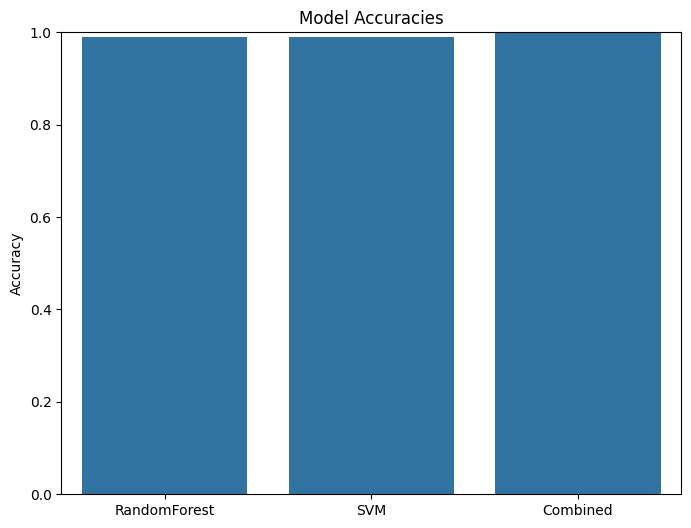

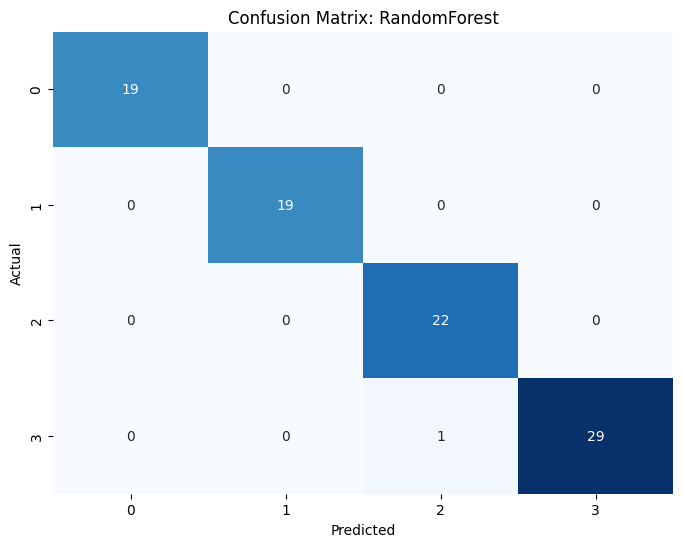

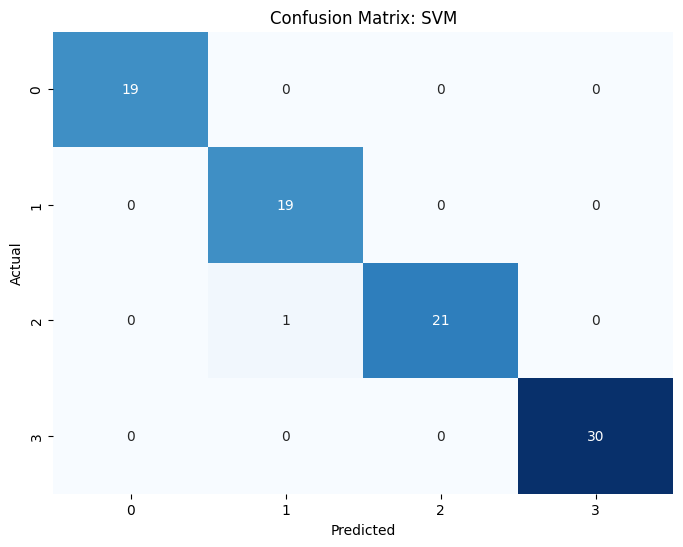

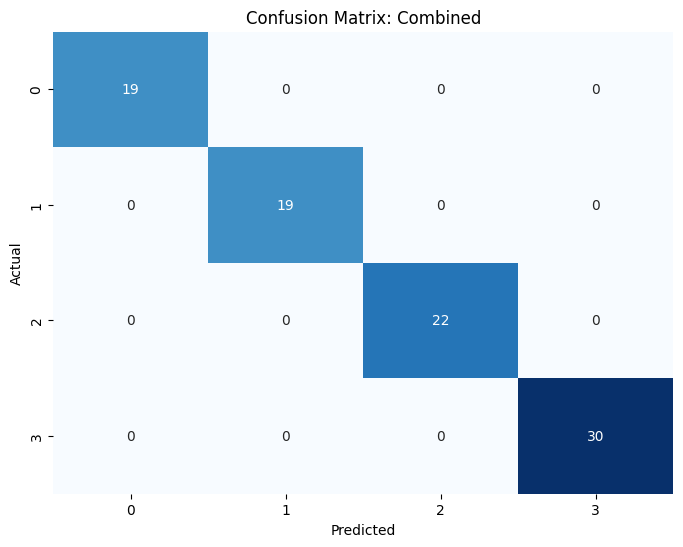

RandomForest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        19
           2       0.96      1.00      0.98        22
           3       1.00      0.97      0.98        30

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.95      1.00      0.97        19
           2       1.00      0.95      0.98        22
           3       1.00      1.00      1.00        30

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90

Combined Classification Report:
              precision    recall  

In [22]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Répertoires des données
train_dir = r'D:\fake accurancy\fake accurancy\Data\train1'
validation_dir = r'D:\fake accurancy\fake accurancy\Data\validation1'

# Prétraitement des images
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # Utilisation du prétraitement spécifique pour ResNet50
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Redimensionnement des images ici
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # Redimensionnement des images ici
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Chargement du modèle pré-entraîné pour l'extraction des caractéristiques
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Extraction des caractéristiques pour les données d'entraînement et de validation
def extract_features(generator, model):
    features = []
    labels = []
    for inputs, batch_labels in generator:
        features.append(model.predict(inputs))
        labels.append(np.argmax(batch_labels, axis=1))
        if generator.batch_index >= generator.samples // generator.batch_size:
            break
    return np.concatenate(features), np.concatenate(labels)

train_features, train_labels = extract_features(train_generator, feature_extractor)
validation_features, validation_labels = extract_features(validation_generator, feature_extractor)

# Séparation des données d'entraînement pour l'entraînement des modèles
X_train, X_test, y_train, y_test = train_test_split(train_features, train_labels, test_size=0.2, random_state=42)

# Entraînement du modèle RandomForest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Entraînement du modèle SVM
svm_model = SVC(probability=True, kernel='linear')
svm_model.fit(X_train, y_train)

# Prédictions des modèles
rf_predictions = rf_model.predict(X_test)
svm_predictions = svm_model.predict(X_test)

# Combinaison des prédictions (moyenne des probabilités pour la fusion)
rf_probs = rf_model.predict_proba(X_test)
svm_probs = svm_model.predict_proba(X_test)

combined_probs = (rf_probs + svm_probs) / 2
combined_predictions = np.argmax(combined_probs, axis=1)

# Évaluation des modèles
rf_accuracy = accuracy_score(y_test, rf_predictions)
svm_accuracy = accuracy_score(y_test, svm_predictions)
combined_accuracy = accuracy_score(y_test, combined_predictions)

print(f'RandomForest Accuracy: {rf_accuracy}')
print(f'SVM Accuracy: {svm_accuracy}')
print(f'Combined Accuracy: {combined_accuracy}')


# Visualisation des résultats
def plot_accuracies():
    accuracies = [rf_accuracy, svm_accuracy, combined_accuracy]
    models = ['RandomForest', 'SVM', 'Combined']

    plt.figure(figsize=(8, 6))
    sns.barplot(x=models, y=accuracies)
    plt.ylim(0, 1)
    plt.title('Model Accuracies')
    plt.ylabel('Accuracy')
    plt.show()

plot_accuracies()

# Matrices de confusion
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion_matrix(y_test, rf_predictions, 'RandomForest')
plot_confusion_matrix(y_test, svm_predictions, 'SVM')
plot_confusion_matrix(y_test, combined_predictions, 'Combined')

# Rapport de classification
print("RandomForest Classification Report:")
print(classification_report(y_test, rf_predictions))
print("SVM Classification Report:")
print(classification_report(y_test, svm_predictions))
print("Combined Classification Report:")
print(classification_report(y_test, combined_predictions))


model.save("RF+SVM.h5")


In [23]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import load_model

# Charger le modèle sauvegardé
model = load_model('RF+SVM.h5')


def preprocess_for_prediction(img):
    img = cv2.resize(img, (224, 224))  # Resize to 224x224 instead of 150x150
    img = np.expand_dims(img, axis=0)
    img = img / 255.0
    return img


cap = cv2.VideoCapture(0)  # Capture depuis la caméra

while True:
    ret, frame = cap.read()
    if not ret:
        break

    preprocessed_frame = preprocess_for_prediction(frame)
    prediction = model.predict(preprocessed_frame)
    class_idx = np.argmax(prediction, axis=1)[0]
    class_labels = ['20', '50', '100', '200']
    label = class_labels[class_idx]
    
    cv2.putText(frame, f"Prediction: {label}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Camera', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━